In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# SETTINGS
# ============================================================
DATATYPE = "Transition Metal"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

WEIGHTED_DATASETS = ["TMD10", "MOR13", "TMB11"]

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"
EV_TO_KCAL = 23.06054783

REUSE_EXISTING_MOLECULE_FILE = True
SAVE_EVERY = 20

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run this notebook from inside the GSCDB project folder.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
mol_log = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_error_log.csv"
rxn_out = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
val_out = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
err_out = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"

mae_out = A / f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rmse_out = A / f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
metric_out = A / f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rel_out = A / f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
long_out = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"
summary_out = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATATYPE:", DATATYPE)

# ============================================================
# HELPERS
# ============================================================
def read_datasets_info(path):
    df = pd.read_csv(path)
    if "Name" in df.columns:
        return df.set_index("Name")
    df = pd.read_csv(path, index_col=0)
    if "Name" in df.columns:
        return df.set_index("Name")
    return df

def reset_calc(calc):
    try:
        calc.reset()
    except Exception:
        pass
    try:
        calc.results = {}
    except Exception:
        pass
    try:
        calc.atoms = None
    except Exception:
        pass

def read_charge_spin(qchem_file):
    charge, spin = 0, 1

    if not qchem_file.exists():
        return charge, spin

    lines = qchem_file.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge = int(float(p[0]))
                    spin = int(float(p[1]))
            break

    return charge, spin

def prepare_atoms(molecule):
    xyz_file = X / f"{molecule}.xyz"
    qchem_file = Q / f"{molecule}.in"

    if not xyz_file.exists():
        raise FileNotFoundError(f"Missing xyz file: {xyz_file}")

    charge, spin = read_charge_spin(qchem_file)
    atoms = read(xyz_file)

    charge = int(float(atoms.info.get("charge", charge)))
    spin = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", spin))))

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin

    # Transition Metal is not an electric-field datatype.
    atoms.info["external_field"] = np.array([0.0, 0.0, 0.0], dtype=float)

    return atoms, charge, spin

def mols_from_stoich(stoich):
    return [p.strip() for p in str(stoich).split(",")][1::2]

def reaction_energy_kcal(stoich, df_mol, model_col):
    parts = [p.strip() for p in str(stoich).split(",")]
    e_ev = 0.0

    for i in range(0, len(parts), 2):
        coef = float(parts[i])
        mol = parts[i + 1]

        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, model_col]):
            return np.nan

        e_ev += coef * float(df_mol.loc[mol, model_col])

    return e_ev * EV_TO_KCAL

def pooled_metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)

    if len(x) == 0:
        return {"N_points": 0, "MAE": np.nan, "RMSE": np.nan, "Pearson_r": np.nan}

    e = y - x

    return {
        "N_points": len(x),
        "MAE": float(np.mean(np.abs(e))),
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "Pearson_r": float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan,
    }

def find_tmc_weight_file():
    for f in [
        I / "DatasetEval_TMC34_weight.csv",
        ROOT / "DatasetEval_TMC34_weight.csv",
        Path.cwd() / "DatasetEval_TMC34_weight.csv",
        Path.cwd().parent / "DatasetEval_TMC34_weight.csv",
    ]:
        if f.exists():
            return f

    raise FileNotFoundError(
        "DatasetEval_TMC34_weight.csv not found. Put it in the Info folder."
    )

def metric_error_for_dataset(dataset, err_series, reaction_index, weights_by_reaction):
    """
    GSCDB metric:
    - Default datasets: MAE.
    - TMD10, MOR13, TMB11:
        weighted estimated MAD =
        sum(abs(error_i) * weight_i) + residual_weight
    """
    err = pd.to_numeric(err_series, errors="coerce")
    reaction_index = list(reaction_index)

    if dataset in WEIGHTED_DATASETS:
        reaction_weights = weights_by_reaction.loc[reaction_index, "Weight"].astype(float)

        all_weight_rows = weights_by_reaction[weights_by_reaction["Dataset"] == dataset]
        residual_rows = all_weight_rows.loc[
            ~all_weight_rows.index.isin(reaction_index)
        ]

        if len(residual_rows) != 1:
            raise ValueError(
                f"{dataset}: expected exactly one residual row, "
                f"but found {len(residual_rows)}."
            )

        residual_weight = float(residual_rows["Weight"].iloc[0])

        return float(
            np.sum(np.abs(err.to_numpy(float)) * reaction_weights.to_numpy(float))
            + residual_weight
        )

    return float(np.mean(np.abs(err)))

# ============================================================
# LOAD FILES
# ============================================================
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_info = read_datasets_info(I / "Datasets.csv")
df_rxn_all = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A / "Results_values.csv", index_col=0)
df_std = pd.read_csv(I / "Standard_errors.csv", index_col=0)

weight_file = find_tmc_weight_file()
df_tmc_weight = pd.read_csv(weight_file)

required_cols = {"Reaction", "Dataset", "Weight"}
if not required_cols.issubset(df_tmc_weight.columns):
    raise ValueError(f"{weight_file} must contain columns: {required_cols}")

weights_by_reaction = df_tmc_weight.set_index("Reaction")

datatype_datasets = df_info.index[df_info["Datatype"].astype(str).eq(DATATYPE)].tolist()

if len(datatype_datasets) == 0:
    print("Available Datatypes:")
    print(sorted(df_info["Datatype"].dropna().unique()))
    raise ValueError(f"No datasets found for Datatype = {DATATYPE}")

ev = df_eval[df_eval["Dataset"].isin(datatype_datasets)].copy()
rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()

print("\nDatasets in this Datatype:")
print(datatype_datasets)
print("Number of datasets:", len(datatype_datasets))
print("Number of data points:", len(ev))
print("TMC weight file:", weight_file)

# ============================================================
# VALIDATE TMD10 / MOR13 / TMB11 WEIGHT FILE
# ============================================================
for ds in WEIGHTED_DATASETS:
    data_reactions = list(ev[ev["Dataset"] == ds].index)
    weight_rows = df_tmc_weight[df_tmc_weight["Dataset"] == ds].copy()

    real_weight_rows = weight_rows[weight_rows["Reaction"].isin(data_reactions)]
    residual_rows = weight_rows[~weight_rows["Reaction"].isin(data_reactions)]

    print(f"\n{ds}:")
    print("Data reactions:", len(data_reactions))
    print("Reaction-weight rows:", len(real_weight_rows))
    print("Residual rows:", len(residual_rows))
    print("Residual row names:", residual_rows["Reaction"].tolist())

    missing_weights = sorted(set(data_reactions) - set(real_weight_rows["Reaction"]))

    if missing_weights:
        raise ValueError(f"Missing reaction weights for {ds}: {missing_weights}")

    if len(real_weight_rows) != len(data_reactions):
        raise ValueError(f"{ds}: real reaction-weight rows do not match data rows.")

    if len(residual_rows) != 1:
        raise ValueError(f"{ds}: expected exactly one residual row, found {len(residual_rows)}.")

# ============================================================
# UNIQUE MOLECULES
# ============================================================
all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols_from_stoich(st)})
print("\nUnique molecules:", len(all_mols))

missing_xyz = [m for m in all_mols if not (X / f"{m}.xyz").exists()]
if missing_xyz:
    print("First missing xyz files:", missing_xyz[:20])
    raise FileNotFoundError(f"{len(missing_xyz)} xyz files are missing.")

# ============================================================
# MOLECULE ENERGY TABLE
# ============================================================
if mol_out.exists() and REUSE_EXISTING_MOLECULE_FILE:
    df_mol = pd.read_csv(mol_out, index_col=0)
    print("\nReusing existing molecule-energy file:")
    print(mol_out)
else:
    df_mol = pd.DataFrame(index=all_mols)
    df_mol.index.name = "Molecule"

for col in ["charge", "spin", "num_atoms", *MODELS.keys()]:
    if col not in df_mol.columns:
        df_mol[col] = np.nan

for mol in all_mols:
    if mol not in df_mol.index:
        df_mol.loc[mol, :] = np.nan

    if pd.isna(df_mol.loc[mol, "num_atoms"]):
        atoms, charge, spin = prepare_atoms(mol)
        df_mol.loc[mol, "charge"] = charge
        df_mol.loc[mol, "spin"] = spin
        df_mol.loc[mol, "num_atoms"] = len(atoms)

# ============================================================
# MACE-POLAR MOLECULAR ENERGIES
# ============================================================
errors = []

for model_col, model_name in MODELS.items():
    print(f"\nLoading {model_col} -> {model_name}")
    calc = mace_polar(model=model_name, device=DEVICE, default_dtype=DTYPE)

    for n, mol in enumerate(tqdm(all_mols, desc=model_col), start=1):
        if REUSE_EXISTING_MOLECULE_FILE and pd.notna(df_mol.loc[mol, model_col]):
            continue

        try:
            atoms, charge, spin = prepare_atoms(mol)
            reset_calc(calc)
            atoms.calc = calc

            df_mol.loc[mol, "charge"] = charge
            df_mol.loc[mol, "spin"] = spin
            df_mol.loc[mol, "num_atoms"] = len(atoms)
            df_mol.loc[mol, model_col] = float(atoms.get_potential_energy())

        except Exception as exc:
            df_mol.loc[mol, model_col] = np.nan
            errors.append({"Molecule": mol, "Model": model_col, "Error": repr(exc)})

        if n % SAVE_EVERY == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)

    del calc
    gc.collect()

    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errors).to_csv(mol_log, index=False)
df_mol.to_csv(mol_out)

print("\nMolecule-energy missing values:")
print(df_mol[list(MODELS)].isna().sum())

if len(errors):
    print("\nFirst MACE errors:")
    print(pd.DataFrame(errors).head(30).to_string(index=False))

# ============================================================
# REACTION ENERGIES
# ============================================================
df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Transition Metal reaction energies"):
    for model_col in MODELS:
        df_rxn.loc[rid, model_col] = reaction_energy_kcal(
            row["Stoichiometry"], df_mol, model_col
        )

df_rxn.to_csv(rxn_out)

print("\nReaction-energy check:")
for model_col in MODELS:
    s = pd.to_numeric(df_rxn[model_col], errors="coerce")
    print(
        model_col,
        "| NaN:", int(s.isna().sum()),
        "| exact zeros:", int(np.isclose(s.dropna(), 0.0).sum()),
        "| unique:", int(s.nunique(dropna=True)),
        "| min/max:", s.min(), s.max(),
    )

# ============================================================
# RESULTS VALUES AND ERRORS
# ============================================================
df_val = val_base.copy()

for model_col in MODELS:
    df_val[model_col] = df_rxn[model_col]

df_val.to_csv(val_out)

df_err = df_val.copy()

for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(
        df_val["Reference"], errors="coerce"
    )

df_err.to_csv(err_out)

# ============================================================
# DATASET-LEVEL MAE, RMSE, METRIC ERROR, NER / MRE
# ============================================================
EVAL_COLS = ["wB97M-V", *MODELS.keys()]

mae_rows, rmse_rows, metric_rows, long_rows = [], [], [], []

for dataset, g_val in df_val.groupby("Dataset"):
    g_err = df_err.loc[g_val.index]
    std_metric = float(df_std.loc[dataset, "Metric"])

    mae_row = {"Dataset": dataset, "Datatype": DATATYPE}
    rmse_row = {"Dataset": dataset, "Datatype": DATATYPE}
    metric_row = {"Dataset": dataset, "Datatype": DATATYPE}

    for col in EVAL_COLS:
        err = pd.to_numeric(g_err[col], errors="coerce")
        complete = bool(err.notna().all())
        n_total = len(err)
        n_used = int(err.notna().sum())

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err ** 2)))
            metric_error = metric_error_for_dataset(
                dataset, err, g_err.index, weights_by_reaction
            )
            ner = metric_error / std_metric
            status = "COMPLETE"
        else:
            mae = rmse = metric_error = ner = np.nan
            status = "INCOMPLETE"

        mae_row[col] = mae
        rmse_row[col] = rmse
        metric_row[col] = metric_error

        long_rows.append({
            "Dataset": dataset,
            "Datatype": DATATYPE,
            "Model": col,
            "Unit": UNIT,
            "N_total": n_total,
            "N_used": n_used,
            "Status": status,
            "MAE": mae,
            "RMSE": rmse,
            "Metric_Error": metric_error,
            "Standard_Error_Metric": std_metric,
            "NER": ner,
        })

    mae_rows.append(mae_row)
    rmse_rows.append(rmse_row)
    metric_rows.append(metric_row)

df_mae = pd.DataFrame(mae_rows).set_index("Dataset").sort_index()
df_rmse = pd.DataFrame(rmse_rows).set_index("Dataset").sort_index()
df_metric = pd.DataFrame(metric_rows).set_index("Dataset").sort_index()
df_long = pd.DataFrame(long_rows)

df_mae.to_csv(mae_out)
df_rmse.to_csv(rmse_out)
df_metric.to_csv(metric_out)

df_rel = df_metric.copy()

for col in EVAL_COLS:
    df_rel[col] = df_metric[col] / df_std.loc[df_metric.index, "Metric"]

df_rel.to_csv(rel_out)
df_long.to_csv(long_out, index=False)

# ============================================================
# DATATYPE SUMMARY
# ============================================================
summary_rows = []

for col in EVAL_COLS:
    pm = pooled_metrics(df_val["Reference"], df_val[col])
    sub = df_long[df_long["Model"] == col]

    summary_rows.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": pm["N_points"],
        "N_datasets_total": len(sub),
        "N_datasets_complete": int((sub["Status"] == "COMPLETE").sum()),
        "N_datasets_incomplete": int((sub["Status"] == "INCOMPLETE").sum()),
        "Pooled_MAE": pm["MAE"],
        "Pooled_RMSE": pm["RMSE"],
        "Pearson_r": pm["Pearson_r"],
        "Mean_Set_MAE": float(sub["MAE"].mean(skipna=True)),
        "Mean_Set_RMSE": float(sub["RMSE"].mean(skipna=True)),
        "Mean_Relative_Error_NER": float(sub["NER"].mean(skipna=True)),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(summary_out, index=False)

print("\nDatatype summary:")
print(df_summary.to_string(index=False))

print("\nSpecial weighted datasets check:")
print(
    df_long[df_long["Dataset"].isin(WEIGHTED_DATASETS)]
    [["Dataset", "Model", "MAE", "Metric_Error", "Standard_Error_Metric", "NER"]]
    .to_string(index=False)
)

# ============================================================
# OPTIONAL: COMPARE wB97M-V MRE AGAINST Analysis/Statistical_errors.csv
# ============================================================
stat_file = A / "Statistical_errors.csv"

if stat_file.exists():
    df_stat = pd.read_csv(stat_file, index_col=0)
    our_wb97mv = float(
        df_summary.loc[
            df_summary["Model"] == "wB97M-V", "Mean_Relative_Error_NER"
        ].iloc[0]
    )

    print("\nComparison with Analysis/Statistical_errors.csv:")

    found = False

    for row_name in ["Mean Transition Metal", "Transition Metal", "TM"]:
        if row_name in df_stat.index and "wB97M-V" in df_stat.columns:
            old = float(df_stat.loc[row_name, "wB97M-V"])
            print("Matched orientation: row = datatype, column = functional")
            print("Row:", row_name)
            print(f"Our wB97M-V MRE/NER        : {our_wb97mv:.10f}")
            print(f"Statistical_errors.csv     : {old:.10f}")
            print(f"Absolute difference        : {abs(our_wb97mv - old):.3e}")
            found = True
            break

    if not found and "wB97M-V" in df_stat.index:
        for col_name in ["Mean Transition Metal", "Transition Metal", "TM"]:
            if col_name in df_stat.columns:
                old = float(df_stat.loc["wB97M-V", col_name])
                print("Matched orientation: row = functional, column = datatype")
                print("Column:", col_name)
                print(f"Our wB97M-V MRE/NER        : {our_wb97mv:.10f}")
                print(f"Statistical_errors.csv     : {old:.10f}")
                print(f"Absolute difference        : {abs(our_wb97mv - old):.3e}")
                found = True
                break

    if not found:
        print("Could not find a direct Transition Metal / wB97M-V entry in Statistical_errors.csv.")
else:
    print("\nNo Analysis/Statistical_errors.csv found. Skipped direct comparison.")

print("\nSaved files:")
for f in [
    mol_out, mol_log, rxn_out, val_out, err_out,
    mae_out, rmse_out, metric_out, rel_out, long_out, summary_out
]:
    print(f)

/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DEVICE: cuda
DATATYPE: Transition Metal

Datasets in this Datatype:
['3d4dIPSS', 'CUAGAU83', 'DAPD', 'MME52', 'MOBH28', 'MOR13', 'ROST61', 'TMB11', 'TMD10']
Number of datasets: 9
Number of data points: 330
TMC weight file: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Info/DatasetEval_TMC34_weight.csv

TMD10:
Data reactions: 10
Reaction-weight rows: 10
Residual rows: 1
Residual row names: ['TMD10_residule']

MOR13:
Data reactions: 13
Reaction-weight rows: 13
Residual rows: 1
Residual row names: ['MOR13_residule']

TMB11:
Data reactions: 11
Reaction-weight rows: 11
Residual rows: 1
Residual row names: ['TMB11_residule']

Unique molecules: 563

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Smodel


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 563/563 [00:52<00:00, 10.76it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Mmodel


mace-polar-1-m: 100%|██████████| 563/563 [01:57<00:00,  4.80it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


mace-polar-1-l: 100%|██████████| 563/563 [04:43<00:00,  1.98it/s]



Molecule-energy missing values:
mace-polar-1-s    19
mace-polar-1-m    19
mace-polar-1-l    19
dtype: int64

First MACE errors:
                  Molecule          Model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Error
              MME55_CDO_1A mace-polar-1-s       OutOfMemoryError('CUDA out of memory. Tried to allocate 7.65 GiB. GPU 0 has a total capacity of 11.63 GiB of which 2.86 GiB is free. Including non-PyTorch memory, this process has 8.31 GiB memory in use. Of the al

Transition Metal reaction energies: 100%|██████████| 330/330 [00:00<00:00, 2606.39it/s]


Reaction-energy check:
mace-polar-1-s | NaN: 16 | exact zeros: 0 | unique: 314 | min/max: -199.38876724082934 454.93941293748674
mace-polar-1-m | NaN: 16 | exact zeros: 0 | unique: 314 | min/max: -206.6071225600658 517.6811479038514
mace-polar-1-l | NaN: 16 | exact zeros: 0 | unique: 314 | min/max: -202.95547123688428 393.79759758940065

Datatype summary:
        Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Transition Metal        wB97M-V kcal/mol       330                 9                    9                      0    3.700144     6.168117   0.997367      3.711135       5.426302                 1.187662
Transition Metal mace-polar-1-s kcal/mol       314                 9                    8                      1   14.369504    24.595563   0.950729     14.964957      20.756835                 4.582100
Transition Metal mace-polar-1-m 

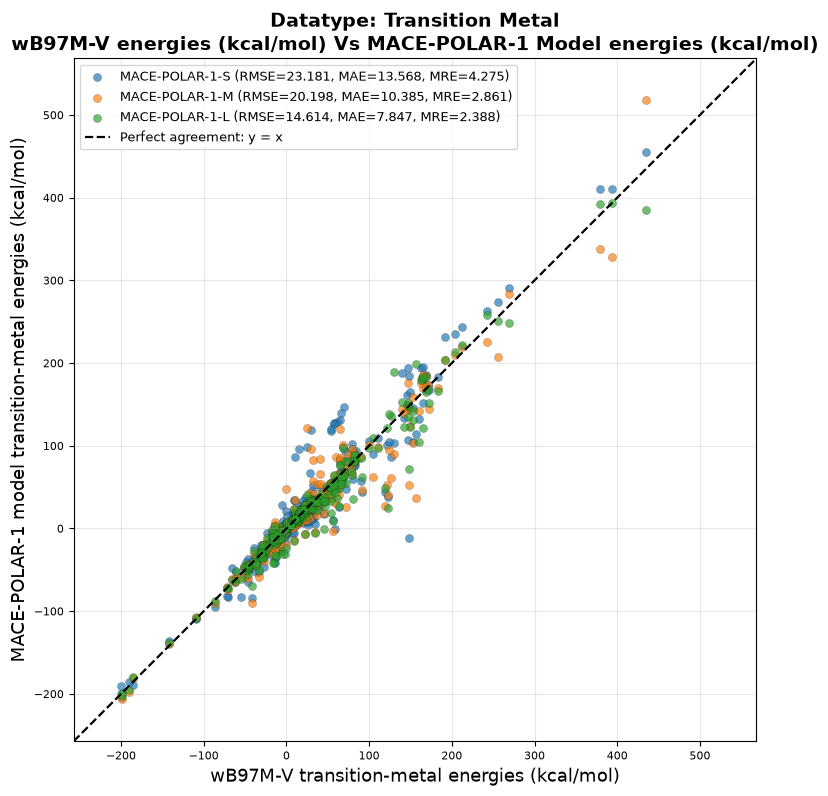

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Transition_Metal_01_wB97M-V_vs_MACE_POLAR_ALL3_V30_style.png


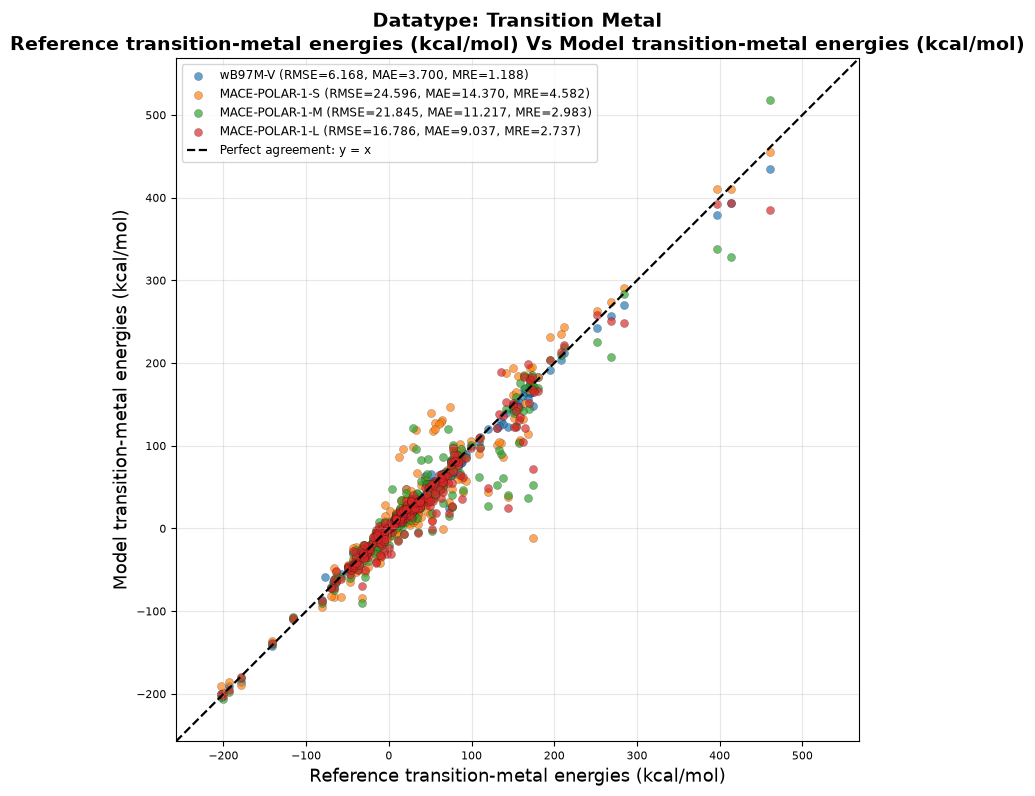

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Transition_Metal_02_Reference_vs_All_Models_V30_style.png


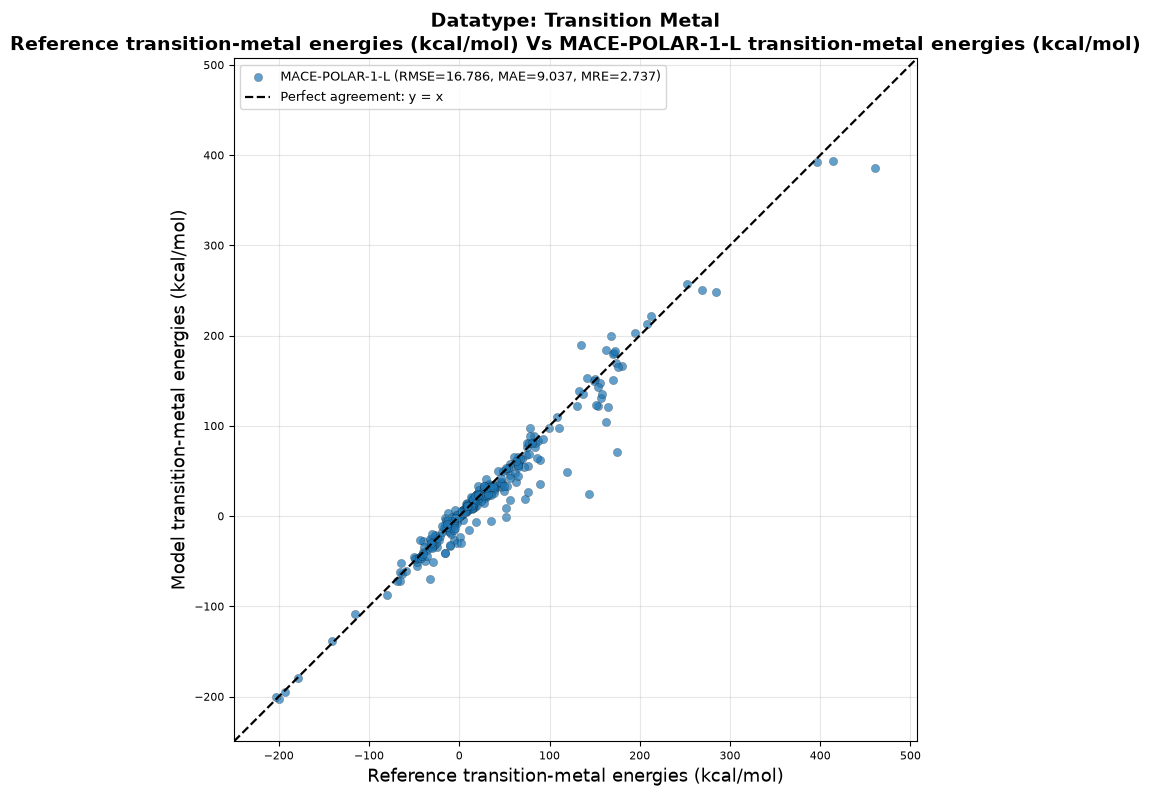

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Transition_Metal_03_Reference_vs_mace-polar-1-l_V30_style.png


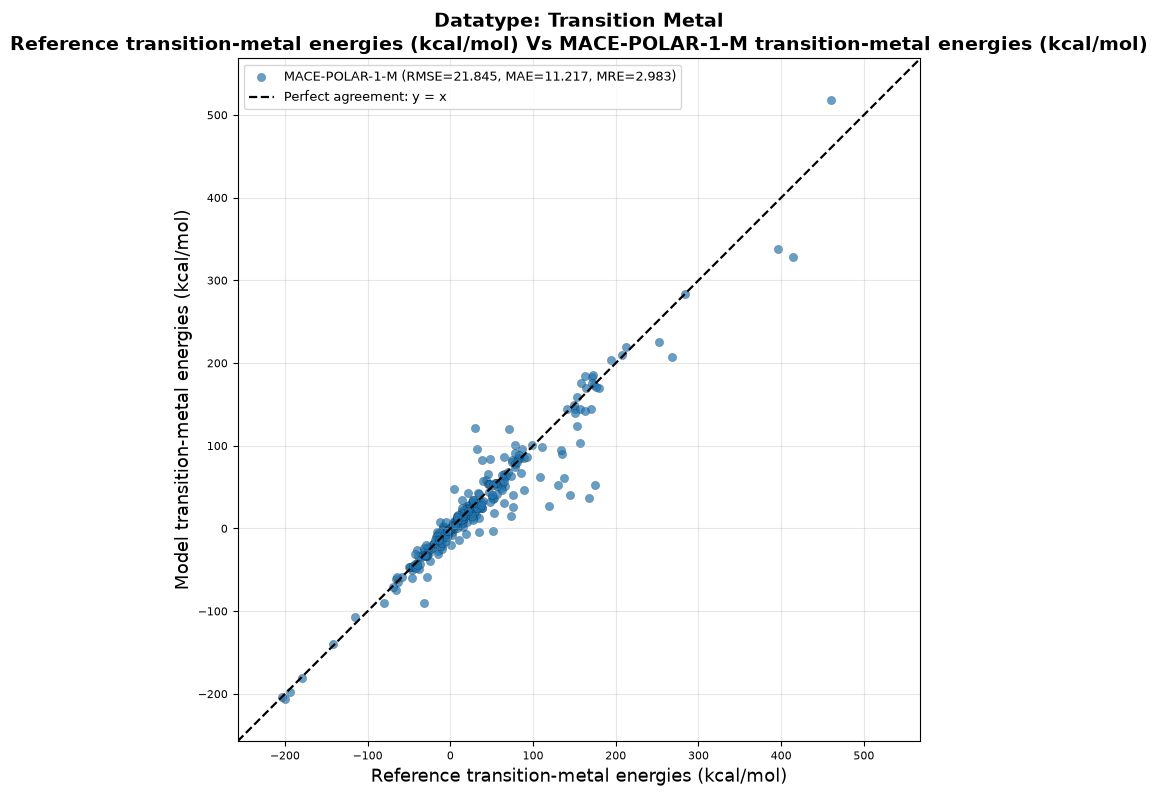

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Transition_Metal_04_Reference_vs_mace-polar-1-m_V30_style.png


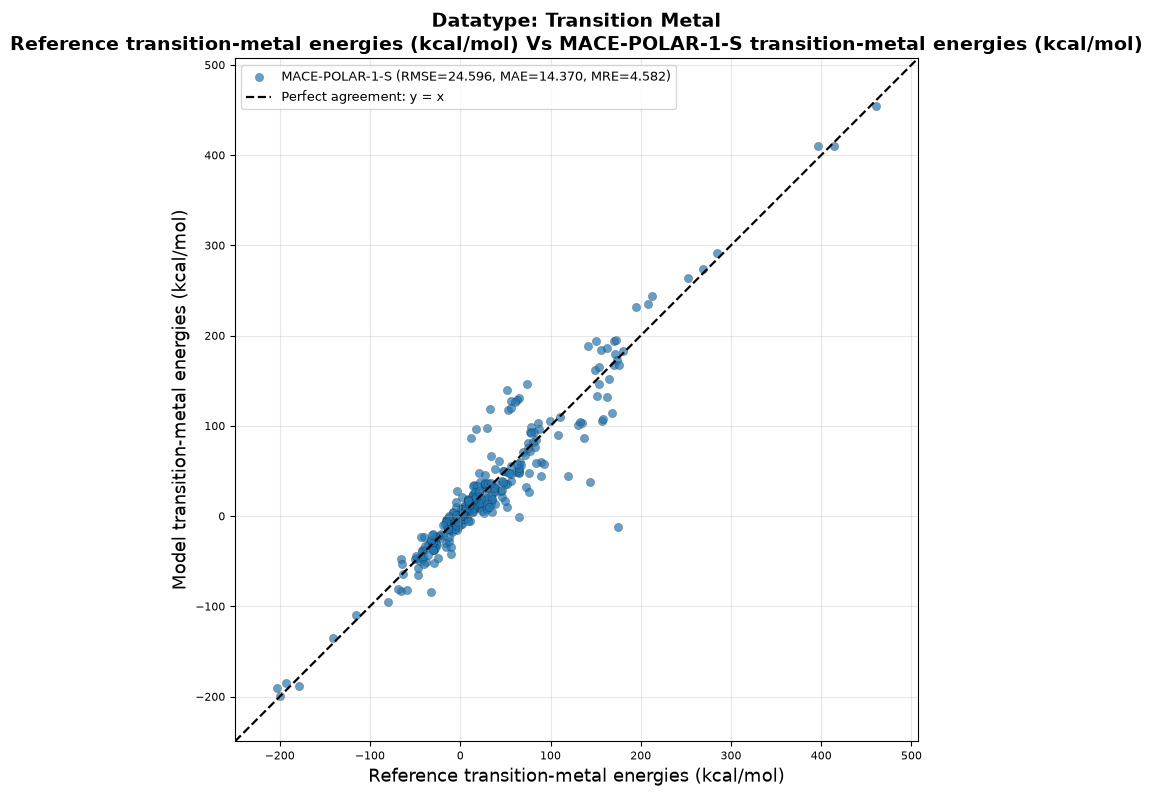

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Transition_Metal_05_Reference_vs_mace-polar-1-s_V30_style.png


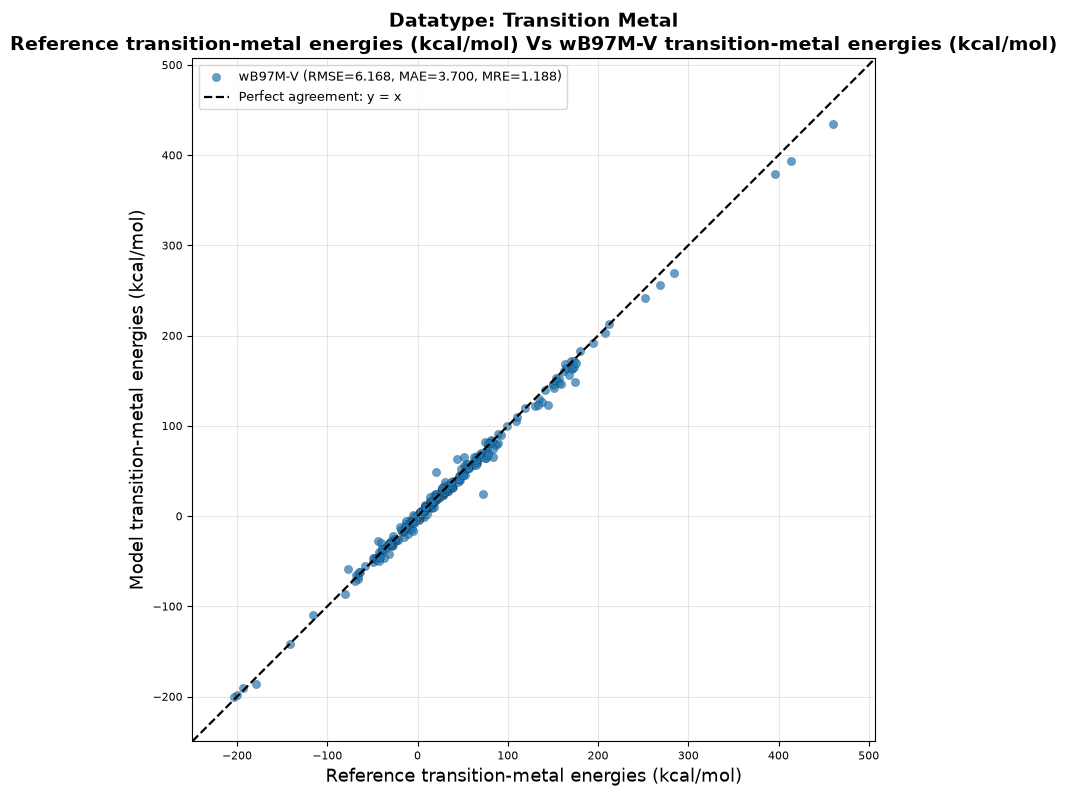

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Transition_Metal_06_Reference_vs_wB97M-V_V30_style.png

Saved plot metrics:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Transition_Metal_V30_style_correlation_plot_metrics.csv

Plot metrics:
                   Plot_Type    X_axis         Y_axis          Model      RMSE       MAE      MRE  Pearson_r   N
             wB97M-V_vs_MACE   wB97M-V mace-polar-1-s MACE-POLAR-1-S 23.180526 13.567970 4.275204   0.956245 314
             wB97M-V_vs_MACE   wB97M-V mace-polar-1-m MACE-POLAR-1-M 20.198203 10.384786 2.861286   0.963564 314
             wB97M-V_vs_MACE   wB97M-V mace-polar-1-l MACE-POLAR-1-L 14.613842  7.847460 2.388346   0.981525 314
            Reference_vs_All Reference        wB97M-V        wB97M-V  6.168117  3.700144 1.187662   0.997367 330
            Reference_vs_All Reference mace-polar-1-s MACE-POLAR-1-S 24.595563 14.369504 4.582100   0.950729 314
            Reference_vs_All Reference mace-

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
DATATYPE = "Transition Metal"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

WEIGHTED_DATASETS = ["TMD10", "MOR13", "TMB11"]

MODELS_ALL = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
MACE_MODELS = ["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q / x).exists() for x in ["Analysis", "Info"]):
            return q
    raise FileNotFoundError("Run this notebook from inside the GSCDB project folder.")

ROOT = find_root()
A, I = ROOT / "Analysis", ROOT / "Info"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
summary_file = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"
std_file = I / "Standard_errors.csv"
weight_file = I / "DatasetEval_TMC34_weight.csv"

df = pd.read_csv(val_file, index_col=0)
summary = pd.read_csv(summary_file)
std = pd.read_csv(std_file, index_col=0)
weights = pd.read_csv(weight_file).set_index("Reaction")

# ============================================================
# HELPERS
# ============================================================
def point_metrics(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)

    if len(x) == 0:
        return {"N": 0, "RMSE": np.nan, "MAE": np.nan, "Pearson_r": np.nan}

    e = y - x

    return {
        "N": len(x),
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "MAE": float(np.mean(np.abs(e))),
        "Pearson_r": float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan,
    }

def get_reference_mre(model):
    return float(
        summary.loc[
            summary["Model"] == model, "Mean_Relative_Error_NER"
        ].iloc[0]
    )

def metric_error_for_dataset(dataset, err, idx):
    """
    For wB97M-V vs MACE plot:
    - Default datasets: MAE.
    - TMD10, MOR13, TMB11:
        sum(abs(error_i) * weight_i) + residual_weight
    """
    err = pd.to_numeric(err, errors="coerce")
    idx = list(idx)

    if dataset in WEIGHTED_DATASETS:
        reaction_weights = weights.loc[idx, "Weight"].astype(float)

        all_weight_rows = weights[weights["Dataset"] == dataset]
        residual_rows = all_weight_rows.loc[
            ~all_weight_rows.index.isin(idx)
        ]

        if len(residual_rows) != 1:
            raise ValueError(
                f"{dataset}: expected exactly one residual row, "
                f"but found {len(residual_rows)}."
            )

        residual_weight = float(residual_rows["Weight"].iloc[0])

        return float(
            np.sum(np.abs(err.to_numpy(float)) * reaction_weights.to_numpy(float))
            + residual_weight
        )

    return float(np.mean(np.abs(err)))

def get_wb97mv_relative_mre(model):
    rows = []

    for dataset, g in df.groupby("Dataset"):
        if dataset not in std.index:
            continue

        d = g[["wB97M-V", model]].dropna()

        if len(d) != len(g):
            continue

        err = pd.to_numeric(d[model], errors="coerce") - pd.to_numeric(
            d["wB97M-V"], errors="coerce"
        )

        metric_error = metric_error_for_dataset(dataset, err, d.index)
        standard_error = float(std.loc[dataset, "Metric"])

        rows.append(metric_error / standard_error)

    return float(np.mean(rows)) if rows else np.nan

def limits_from_columns(dataframe, x_col, y_cols):
    arrs = [pd.to_numeric(dataframe[x_col], errors="coerce").dropna().to_numpy(float)]

    for col in y_cols:
        arrs.append(pd.to_numeric(dataframe[col], errors="coerce").dropna().to_numpy(float))

    values = np.concatenate(arrs)
    lo, hi = np.nanmin(values), np.nanmax(values)
    pad = 0.07 * (hi - lo) if hi > lo else 1.0

    return lo - pad, hi + pad

def save_plot(out):
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved:", out)

plot_metric_rows = []

# ============================================================
# PLOT 1: wB97M-V vs all three MACE-POLAR models
# ============================================================
lo, hi = limits_from_columns(df, "wB97M-V", MACE_MODELS)

plt.figure(figsize=(10, 8))

for model in MACE_MODELS:
    m = point_metrics(df["wB97M-V"], df[model])
    mre = get_wb97mv_relative_mre(model)

    plot_metric_rows.append({
        "Plot_Type": "wB97M-V_vs_MACE",
        "X_axis": "wB97M-V",
        "Y_axis": model,
        "Model": LABELS[model],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "MRE": mre,
        "Pearson_r": m["Pearson_r"],
        "N": m["N"],
    })

    plt.scatter(
        df["wB97M-V"],
        df[model],
        s=34,
        alpha=0.68,
        edgecolors="black",
        linewidths=0.18,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.6, label="Perfect agreement: y = x")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("wB97M-V transition-metal energies (kcal/mol)", fontsize=13)
plt.ylabel("MACE-POLAR-1 model transition-metal energies (kcal/mol)", fontsize=13)
plt.title(
    "Datatype: Transition Metal\n"
    "wB97M-V energies (kcal/mol) Vs MACE-POLAR-1 Model energies (kcal/mol)",
    fontsize=14,
    fontweight="bold",
)
plt.grid(alpha=0.3)
plt.legend(fontsize=9)

out = FIG / f"{TAG}_01_wB97M-V_vs_MACE_POLAR_ALL3_V30_style.png"
save_plot(out)

# ============================================================
# PLOT 2: Reference vs wB97M-V + all three MACE models
# ============================================================
lo, hi = limits_from_columns(df, "Reference", MODELS_ALL)

plt.figure(figsize=(10, 8))

for model in MODELS_ALL:
    m = point_metrics(df["Reference"], df[model])
    mre = get_reference_mre(model)

    plot_metric_rows.append({
        "Plot_Type": "Reference_vs_All",
        "X_axis": "Reference",
        "Y_axis": model,
        "Model": LABELS[model],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "MRE": mre,
        "Pearson_r": m["Pearson_r"],
        "N": m["N"],
    })

    plt.scatter(
        df["Reference"],
        df[model],
        s=34,
        alpha=0.68,
        edgecolors="black",
        linewidths=0.18,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.6, label="Perfect agreement: y = x")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Reference transition-metal energies (kcal/mol)", fontsize=13)
plt.ylabel("Model transition-metal energies (kcal/mol)", fontsize=13)
plt.title(
    "Datatype: Transition Metal\n"
    "Reference transition-metal energies (kcal/mol) Vs Model transition-metal energies (kcal/mol)",
    fontsize=14,
    fontweight="bold",
)
plt.grid(alpha=0.3)
plt.legend(fontsize=8.5)

out = FIG / f"{TAG}_02_Reference_vs_All_Models_V30_style.png"
save_plot(out)

# ============================================================
# PLOTS 3, 4, 5: Reference vs MACE-L, MACE-M, MACE-S
# ============================================================
individual_order = ["mace-polar-1-l", "mace-polar-1-m", "mace-polar-1-s"]

for plot_number, model in zip([3, 4, 5], individual_order):
    m = point_metrics(df["Reference"], df[model])
    mre = get_reference_mre(model)
    lo, hi = limits_from_columns(df, "Reference", [model])

    plot_metric_rows.append({
        "Plot_Type": "Reference_vs_Individual_MACE",
        "X_axis": "Reference",
        "Y_axis": model,
        "Model": LABELS[model],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "MRE": mre,
        "Pearson_r": m["Pearson_r"],
        "N": m["N"],
    })

    plt.figure(figsize=(10, 8))

    plt.scatter(
        df["Reference"],
        df[model],
        s=36,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.18,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

    plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.6, label="Perfect agreement: y = x")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Reference transition-metal energies (kcal/mol)", fontsize=13)
    plt.ylabel("Model transition-metal energies (kcal/mol)", fontsize=13)
    plt.title(
        f"Datatype: Transition Metal\n"
        f"Reference transition-metal energies (kcal/mol) Vs {LABELS[model]} transition-metal energies (kcal/mol)",
        fontsize=14,
        fontweight="bold",
    )
    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)

    out = FIG / f"{TAG}_0{plot_number}_Reference_vs_{model}_V30_style.png"
    save_plot(out)

# ============================================================
# PLOT 6: Reference vs wB97M-V
# ============================================================
model = "wB97M-V"
m = point_metrics(df["Reference"], df[model])
mre = get_reference_mre(model)
lo, hi = limits_from_columns(df, "Reference", [model])

plot_metric_rows.append({
    "Plot_Type": "Reference_vs_wB97M-V",
    "X_axis": "Reference",
    "Y_axis": model,
    "Model": LABELS[model],
    "RMSE": m["RMSE"],
    "MAE": m["MAE"],
    "MRE": mre,
    "Pearson_r": m["Pearson_r"],
    "N": m["N"],
})

plt.figure(figsize=(10, 8))

plt.scatter(
    df["Reference"],
    df[model],
    s=36,
    alpha=0.70,
    edgecolors="black",
    linewidths=0.18,
    label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
)

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.6, label="Perfect agreement: y = x")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Reference transition-metal energies (kcal/mol)", fontsize=13)
plt.ylabel("Model transition-metal energies (kcal/mol)", fontsize=13)
plt.title(
    "Datatype: Transition Metal\n"
    "Reference transition-metal energies (kcal/mol) Vs wB97M-V transition-metal energies (kcal/mol)",
    fontsize=14,
    fontweight="bold",
)
plt.grid(alpha=0.3)
plt.legend(fontsize=9)

out = FIG / f"{TAG}_06_Reference_vs_wB97M-V_V30_style.png"
save_plot(out)

# ============================================================
# SAVE PLOT METRICS
# ============================================================
plot_metrics = pd.DataFrame(plot_metric_rows)
plot_metrics_out = A / f"{TAG}_V30_style_correlation_plot_metrics.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)

print("\nPlot metrics:")
print(plot_metrics.to_string(index=False))